# CIC-IDS2017 — Warning Set Threshold Search + Online Training (HST)

In [1]:
import os
import glob
import numpy as np
import pandas as pd
from collections import deque
import matplotlib.pyplot as plt
from river import anomaly, compose, preprocessing, feature_selection, drift, metrics as river_metrics
from sklearn.metrics import roc_curve, auc
import joblib
import csv
import time
from pympler import asizeof

In [ ]:
DATA_DIR  = 'CIC-IDS2017'
LABEL_COL = 'Label'
cat_cols  = []

_f = sorted(glob.glob(os.path.join(DATA_DIR, '*.parquet')))[0]
_df = pd.read_parquet(_f).head(2)

if ' Label' in _df.columns and LABEL_COL not in _df.columns:
    LABEL_COL = ' Label'

num_cols = [c for c in _df.columns if c != LABEL_COL and c not in cat_cols]

print(f"Label column       : {repr(LABEL_COL)}")
print(f"Numerical columns  : {len(num_cols)}")
print(f"Categorical columns: {cat_cols}")

Label column       : 'Label'
Numerical columns  : 77
Categorical columns: []


In [3]:
all_files = sorted(glob.glob(os.path.join(DATA_DIR, '*.parquet')))
print(f"Ficheiros encontrados: {len(all_files)}")
for f in all_files:
    print(f"  {os.path.basename(f)}")

Ficheiros encontrados: 8
  Benign-Monday-no-metadata.parquet
  Botnet-Friday-no-metadata.parquet
  Bruteforce-Tuesday-no-metadata.parquet
  DDoS-Friday-no-metadata.parquet
  DoS-Wednesday-no-metadata.parquet
  Infiltration-Thursday-no-metadata.parquet
  Portscan-Friday-no-metadata.parquet
  WebAttacks-Thursday-no-metadata.parquet


In [ ]:
def stream_interleaved(file_list, max_rows=None, skip=0):
    dfs = []
    for path in file_list:
        df = pd.read_parquet(path, engine='pyarrow')
        df.replace([float('inf'), float('-inf')], float('nan'), inplace=True)
        df.dropna(inplace=True)
        df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle interno
        dfs.append(df)

    iterators  = [df.iterrows() for df in dfs]
    active     = list(range(len(iterators)))
    yielded    = 0
    skipped    = 0

    while active:
        next_active = []
        for i in active:
            try:
                _, row = next(iterators[i])
            except StopIteration:
                continue

            if skipped < skip:
                skipped += 1
                next_active.append(i)
                continue
            if max_rows is not None and yielded >= max_rows:
                return

            x = {}
            for col in num_cols:
                x[col] = float(row[col])
            for col in cat_cols:
                x[col] = str(row[col])

            label_val = str(row[LABEL_COL]).strip().upper()
            y = 0 if label_val in ('BENIGN', 'NORMAL', '0') else 1

            yield x, y
            yielded += 1
            next_active.append(i)

        active = next_active

In [5]:
VARIANCE_THRESHOLD = 0.01

model = compose.Pipeline(
    compose.Select(*num_cols),
    preprocessing.MinMaxScaler(),
    feature_selection.VarianceThreshold(),
    anomaly.HalfSpaceTrees(
        n_trees=50,
        height=10,
        window_size=500,
        seed=42
    )
)

## Warning Set

In [ ]:
WARNING_SET_SIZE = 10_000
warning_scores  = []
warning_labels  = []

for i, (x, y) in enumerate(stream_interleaved(all_files, max_rows=WARNING_SET_SIZE)):
    score = model.score_one(x)
    warning_scores.append(score)
    warning_labels.append(y)
    model.learn_one(x)

warning_scores = np.array(warning_scores)
warning_labels = np.array(warning_labels)

print(f"Warning-set examples : {len(warning_scores)}")
print(f"  anomalies          : {warning_labels.sum()}  ({warning_labels.mean()*100:.1f} %)")
print(f"  normal             : {(1 - warning_labels).sum()}")
print(f"Score range          : [{warning_scores.min():.4f}, {warning_scores.max():.4f}]")
print(f"Score mean / std     : {warning_scores.mean():.4f} / {warning_scores.std():.4f}")


Warning-set examples : 10000
  anomalies          : 1220  (12.2 %)
  normal             : 8780
Score range          : [0.0000, 0.9607]
Score mean / std     : 0.3373 / 0.1822


### Threshold selection — F1 grid search on warning set

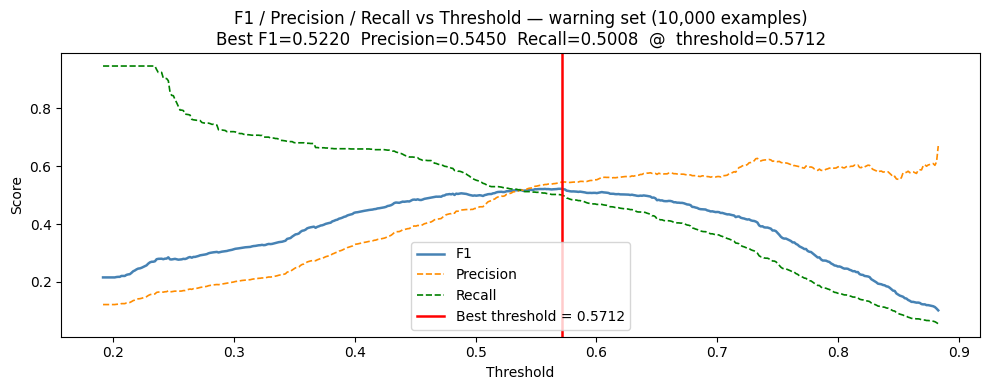

In [7]:
grid_thresholds = np.linspace(
    np.percentile(warning_scores, 5),
    np.percentile(warning_scores, 99),
    500
)

grid_results = []
for thr in grid_thresholds:
    y_pred = (warning_scores >= thr).astype(int)
    tp = int(((y_pred == 1) & (warning_labels == 1)).sum())
    fp = int(((y_pred == 1) & (warning_labels == 0)).sum())
    fn = int(((y_pred == 0) & (warning_labels == 1)).sum())
    prec   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_val = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    grid_results.append({"threshold": thr, "precision": prec, "recall": rec, "f1": f1_val})

grid_df   = pd.DataFrame(grid_results)
best_row  = grid_df.loc[grid_df["f1"].idxmax()]
THRESHOLD = best_row["threshold"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(grid_df["threshold"], grid_df["f1"],        color="steelblue",  lw=1.8, label="F1")
ax.plot(grid_df["threshold"], grid_df["precision"], color="darkorange", lw=1.2, ls="--", label="Precision")
ax.plot(grid_df["threshold"], grid_df["recall"],    color="green",      lw=1.2, ls="--", label="Recall")
ax.axvline(THRESHOLD, color="red", lw=1.8, label=f"Best threshold = {THRESHOLD:.4f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title(
    f"F1 / Precision / Recall vs Threshold — warning set ({WARNING_SET_SIZE:,} examples)\n"
    f"Best F1={best_row['f1']:.4f}  Precision={best_row['precision']:.4f}  "
    f"Recall={best_row['recall']:.4f}  @  threshold={THRESHOLD:.4f}"
)
ax.legend()
plt.tight_layout()
plt.savefig("warning_set_threshold_grid_ids2017.png", dpi=150)
plt.show()


## Online unsupervised training

In [ ]:
adwin_train        = drift.ADWIN()
drift_events_train = []
train_scores_hst   = list(warning_scores)
score_window       = deque(maxlen=500)
warmup_adwin       = 50
i                  = -1

for i, (x, _) in enumerate(stream_interleaved(all_files, skip=WARNING_SET_SIZE)):
    score = model.score_one(x)
    train_scores_hst.append(score)

    adwin_train.update(score)
    if i >= warmup_adwin and adwin_train.drift_detected:
        drift_events_train.append((i + WARNING_SET_SIZE, score))
        adwin_train = drift.ADWIN()

    score_window.append(score)
    model.learn_one(x)

total_train = WARNING_SET_SIZE + i + 1
print(f"Training finished — {total_train:,} total examples processed.")
print(f"  Warning set : {WARNING_SET_SIZE:,}")
print(f"  Incremental : {i + 1:,}")
print(f"Drift events detected : {len(drift_events_train)}")
if drift_events_train:
    print(f"First {len(drift_events_train)} drift events (index, score):")
    for idx, sc in drift_events_train[:5]:
        print(f"  {idx} -> {sc:.6f}")

joblib.dump(model, "hst_model_ids2017.pkl")
print("Model saved to hst_model_ids2017.pkl")

Training finished — 2,313,810 total examples processed.
  Warning set : 10,000
  Incremental : 2,303,810
Drift events detected : 41
First 41 drift events (index, score):
  75887 -> 0.713144
  105135 -> 0.436330
  105583 -> 0.227179
  115279 -> 0.215704
  176207 -> 0.185064
Model saved to hst_model_ids2017.pkl


## Evaluation on test set

In [ ]:
test_files = [f for f in all_files if 'Benign' not in os.path.basename(f)]
print("Test files:")
for f in test_files: print(f"  {os.path.basename(f)}")

def stream_sequential(file_list):
    """Stream sequencial simples para avaliação (sem intercalação)."""
    for path in file_list:
        df = pd.read_parquet(path, engine='pyarrow')
        df.replace([float('inf'), float('-inf')], float('nan'), inplace=True)
        df.dropna(inplace=True)
        for _, row in df.iterrows():
            x = {col: float(row[col]) for col in num_cols}
            label_val = str(row[LABEL_COL]).strip().upper()
            y = 0 if label_val in ('BENIGN', 'NORMAL', '0') else 1
            yield x, y

Test files:
  Botnet-Friday-no-metadata.parquet
  Bruteforce-Tuesday-no-metadata.parquet
  DDoS-Friday-no-metadata.parquet
  DoS-Wednesday-no-metadata.parquet
  Infiltration-Thursday-no-metadata.parquet
  Portscan-Friday-no-metadata.parquet
  WebAttacks-Thursday-no-metadata.parquet


In [10]:
roc_auc   = river_metrics.ROCAUC()
f1        = river_metrics.F1()
precision = river_metrics.Precision()
recall    = river_metrics.Recall()
gmean     = river_metrics.GeometricMean()
cm        = river_metrics.ConfusionMatrix()

t_score_total = 0
n_test = 0

for x, y_true in stream_sequential(test_files):
    t0 = time.perf_counter()
    score = model.score_one(x)
    t_score_total += time.perf_counter() - t0

    y_pred = 1 if score >= THRESHOLD else 0

    roc_auc.update(y_true, score)
    f1.update(y_true, y_pred)
    precision.update(y_true, y_pred)
    recall.update(y_true, y_pred)
    gmean.update(y_true, y_pred)
    cm.update(y_true, y_pred)

    n_test += 1

t_medio = (t_score_total / n_test) * 1000

tp = cm.data[1][1]
fp = cm.data[0][1]
tn = cm.data[0][0]
fn = cm.data[1][0]

print(f"Threshold  : {THRESHOLD:.4f}")
print(f"ROCAUC     : {roc_auc.get():.4f}")
print(f"Precision  : {precision.get():.4f}")
print(f"Recall     : {recall.get():.4f}")
print(f"F1         : {f1.get():.4f}")
print(f"G-Mean     : {gmean.get():.4f}")
print(f"TP={tp}  FP={fp}  TN={tn}  FN={fn}")
print(f"Avg Time   : {t_medio:.4f} ms/instância")
print(f"Memory     : {asizeof.asizeof(model) / 1024:.1f} KB")

Threshold  : 0.5712
ROCAUC     : 0.8078
Precision  : 0.6698
Recall     : 0.5158
F1         : 0.5828
G-Mean     : 0.6976
TP=173548.0  FP=85546.0  TN=1432941.0  FN=162944.0
Avg Time   : 1.0847 ms/instância
Memory     : 25703.9 KB


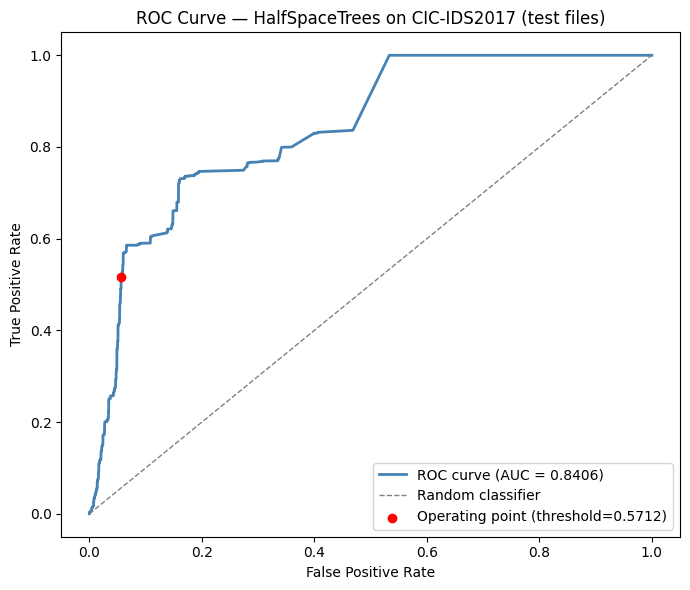

In [11]:
all_scores = []
all_labels = []

for x, y_true in stream_sequential(test_files):
    all_scores.append(model.score_one(x))
    all_labels.append(y_true)

fpr, tpr, _ = roc_curve(all_labels, all_scores)
roc_auc_sk  = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {roc_auc_sk:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random classifier")
ax.scatter(fp / (fp + tn) if (fp + tn) > 0 else 0,
           tp / (tp + fn) if (tp + fn) > 0 else 0,
           color="red", zorder=5,
           label=f"Operating point (threshold={THRESHOLD:.4f})")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — HalfSpaceTrees on CIC-IDS2017 (test files)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_hst_ids2017.png", dpi=150)
plt.show()


In [12]:
records = []

for i, (x, y_true) in enumerate(stream_sequential(test_files)):
    score  = model.score_one(x)
    y_pred = 1 if score >= THRESHOLD else 0
    row    = {"index": i, "score": score, "y_true": y_true, "y_pred": y_pred}
    row.update(x)
    records.append(row)

scores_df = pd.DataFrame(records)
scores_df.to_csv("anomaly_scores_hst_ids2017.csv", index=False)
print(f"anomaly_scores_hst_ids2017.csv saved — {len(scores_df):,} rows, {len(scores_df.columns)} columns.")


anomaly_scores_hst_ids2017.csv saved — 1,854,979 rows, 81 columns.


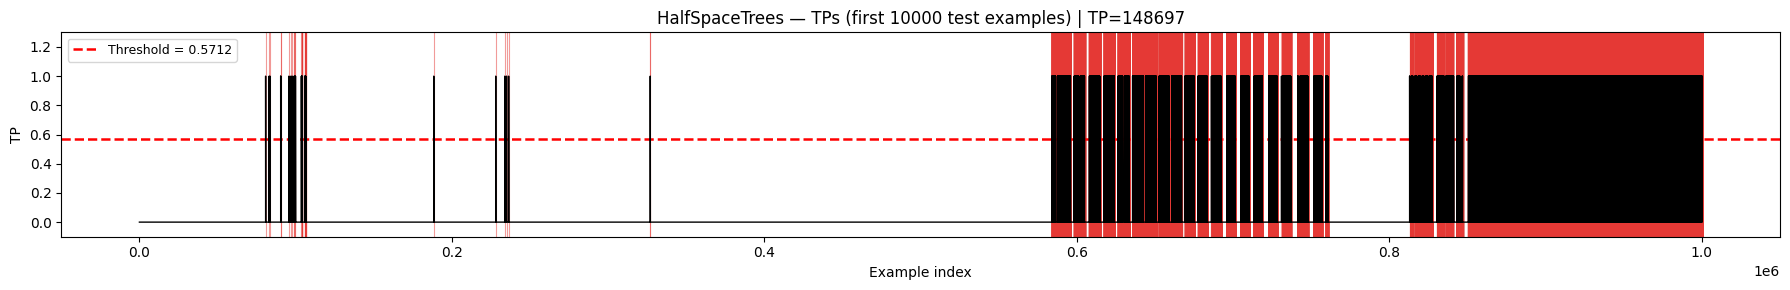

In [ ]:
df_plot     = pd.read_csv("anomaly_scores_hst_ids2017.csv").iloc[:1000000]
test_scores = df_plot["score"].values
test_labels = df_plot["y_true"].values
indices     = df_plot["index"].values

fig, ax = plt.subplots(figsize=(18, 3))

y_pred_plot = (test_scores >= THRESHOLD).astype(int)
tp_signal   = ((test_labels == 1) & (y_pred_plot == 1)).astype(int)
tp_mask     = tp_signal.astype(bool)

for idx in indices[tp_mask]:
    ax.axvline(idx, color="#e53935", linewidth=0.8, alpha=0.5, zorder=1)

ax.step(indices, tp_signal, where="post", color="black", linewidth=1.0, zorder=3)
ax.axhline(THRESHOLD, color="red", linestyle="--", linewidth=1.8,
           label=f"Threshold = {THRESHOLD:.4f}")

ax.set_ylabel("TP")
ax.set_xlabel("Example index")
ax.set_title(f"HalfSpaceTrees — TPs (first 1000000 test examples) | TP={tp_signal.sum()}")
ax.set_ylim(-0.1, 1.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("anomaly_scores_tp_warningset_hst_ids2017.png", dpi=150)
plt.show()